# Project 4: News Recommendation System (MIND Dataset)


In [5]:
import pandas as pd
import os

news_file_path = '/kaggle/input/mindataset/news.tsv'
news_df = pd.read_csv(news_file_path, sep='\t', header=None)

# Display the first few rows
print("News Data Sample:")
print(news_df.head())

News Data Sample:
        0          1                2  \
0  N55528  lifestyle  lifestyleroyals   
1  N19639     health       weightloss   
2  N61837       news        newsworld   
3  N53526     health           voices   
4  N38324     health          medical   

                                                   3  \
0  The Brands Queen Elizabeth, Prince Charles, an...   
1                      50 Worst Habits For Belly Fat   
2  The Cost of Trump's Aid Freeze in the Trenches...   
3  I Was An NBA Wife. Here's How It Affected My M...   
4  How to Get Rid of Skin Tags, According to a De...   

                                                   4  \
0  Shop the notebooks, jackets, and more that the...   
1  These seemingly harmless habits are holding yo...   
2  Lt. Ivan Molchanets peeked over a parapet of s...   
3  I felt like I was a fraud, and being an NBA wi...   
4  They seem harmless, but there's a very good re...   

                                               5  \
0  https:

In [6]:
behaviors_file_path = '/kaggle/input/mindataset/behaviors.tsv'
behaviors_df = pd.read_csv(behaviors_file_path, sep='\t', header=None)

# Display the first few rows
print("Behaviors Data Sample:")
print(behaviors_df.head())

Behaviors Data Sample:
   0       1                      2  \
0  1  U13740  11/11/2019 9:05:58 AM   
1  2  U91836  11/12/2019 6:11:30 PM   
2  3  U73700  11/14/2019 7:01:48 AM   
3  4  U34670  11/11/2019 5:28:05 AM   
4  5   U8125  11/12/2019 4:11:21 PM   

                                                   3  \
0  N55189 N42782 N34694 N45794 N18445 N63302 N104...   
1  N31739 N6072 N63045 N23979 N35656 N43353 N8129...   
2  N10732 N25792 N7563 N21087 N41087 N5445 N60384...   
3  N45729 N2203 N871 N53880 N41375 N43142 N33013 ...   
4                        N10078 N56514 N14904 N33740   

                                                   4  
0                                  N55689-1 N35729-0  
1  N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N...  
2  N50014-0 N23877-0 N35389-0 N49712-0 N16844-0 N...  
3                N35729-0 N33632-0 N49685-1 N27581-0  
4  N39985-0 N36050-0 N16096-0 N8400-1 N22407-0 N6...  


# Cleaning & Structuring news_df (News Data)

In [7]:
# Renaming columns for clarity
news_df.columns = [
    'NewsID', 'Category', 'Subcategory', 'Title', 'Abstract', 
    'URL', 'Title_Entities', 'Abstract_Entities'
]
# Displaying the first few rows to confirm changes
print(news_df.head())


   NewsID   Category      Subcategory  \
0  N55528  lifestyle  lifestyleroyals   
1  N19639     health       weightloss   
2  N61837       news        newsworld   
3  N53526     health           voices   
4  N38324     health          medical   

                                               Title  \
0  The Brands Queen Elizabeth, Prince Charles, an...   
1                      50 Worst Habits For Belly Fat   
2  The Cost of Trump's Aid Freeze in the Trenches...   
3  I Was An NBA Wife. Here's How It Affected My M...   
4  How to Get Rid of Skin Tags, According to a De...   

                                            Abstract  \
0  Shop the notebooks, jackets, and more that the...   
1  These seemingly harmless habits are holding yo...   
2  Lt. Ivan Molchanets peeked over a parapet of s...   
3  I felt like I was a fraud, and being an NBA wi...   
4  They seem harmless, but there's a very good re...   

                                             URL  \
0  https://assets.msn.com/l

In [8]:
# Checking for missing values in each column
print("Missing Values in news_df:")
print(news_df.isnull().sum())

Missing Values in news_df:
NewsID                  0
Category                0
Subcategory             0
Title                   0
Abstract             2666
URL                     0
Title_Entities          3
Abstract_Entities       4
dtype: int64


In [9]:
# Dropping rows with missing 'Title' or 'Abstract'
news_df.dropna(subset=['Title', 'Abstract'], inplace=True)

# Displaying the remaining rows
print("Remaining rows after dropping missing values:", len(news_df))

Remaining rows after dropping missing values: 48616


# Cleaning & Structuring behaviors_df (User Interaction Data)

In [10]:
# Renaming columns for clarity
behaviors_df.columns = [
    'ImpressionID', 'UserID', 'Timestamp', 'History', 'Impressions'
]
# Displaying the first few rows to confirm changes
print(behaviors_df.head())


   ImpressionID  UserID              Timestamp  \
0             1  U13740  11/11/2019 9:05:58 AM   
1             2  U91836  11/12/2019 6:11:30 PM   
2             3  U73700  11/14/2019 7:01:48 AM   
3             4  U34670  11/11/2019 5:28:05 AM   
4             5   U8125  11/12/2019 4:11:21 PM   

                                             History  \
0  N55189 N42782 N34694 N45794 N18445 N63302 N104...   
1  N31739 N6072 N63045 N23979 N35656 N43353 N8129...   
2  N10732 N25792 N7563 N21087 N41087 N5445 N60384...   
3  N45729 N2203 N871 N53880 N41375 N43142 N33013 ...   
4                        N10078 N56514 N14904 N33740   

                                         Impressions  
0                                  N55689-1 N35729-0  
1  N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N...  
2  N50014-0 N23877-0 N35389-0 N49712-0 N16844-0 N...  
3                N35729-0 N33632-0 N49685-1 N27581-0  
4  N39985-0 N36050-0 N16096-0 N8400-1 N22407-0 N6...  


In [11]:
# Checking for missing values
print("Missing Values in behaviors_df:")
print(behaviors_df.isnull().sum())

Missing Values in behaviors_df:
ImpressionID       0
UserID             0
Timestamp          0
History         3238
Impressions        0
dtype: int64


In [12]:
# Convert 'History' into a list of articles the user has previously interacted with
behaviors_df['History'] = behaviors_df['History'].apply(lambda x: x.split() if isinstance(x, str) else [])

In [13]:
# Splitting Impressions and extracting NewsID-Label pairs
def parse_impressions(impression_str):
    if isinstance(impression_str, str):
        impressions = impression_str.split()
        return [(imp.split('-')[0], int(imp.split('-')[1])) for imp in impressions]
    return []

# Applying the parsing function to the 'Impressions' column
behaviors_df['Impressions'] = behaviors_df['Impressions'].apply(parse_impressions)

# Displaying the processed data
print(behaviors_df.head())


   ImpressionID  UserID              Timestamp  \
0             1  U13740  11/11/2019 9:05:58 AM   
1             2  U91836  11/12/2019 6:11:30 PM   
2             3  U73700  11/14/2019 7:01:48 AM   
3             4  U34670  11/11/2019 5:28:05 AM   
4             5   U8125  11/12/2019 4:11:21 PM   

                                             History  \
0  [N55189, N42782, N34694, N45794, N18445, N6330...   
1  [N31739, N6072, N63045, N23979, N35656, N43353...   
2  [N10732, N25792, N7563, N21087, N41087, N5445,...   
3  [N45729, N2203, N871, N53880, N41375, N43142, ...   
4                   [N10078, N56514, N14904, N33740]   

                                         Impressions  
0                         [(N55689, 1), (N35729, 0)]  
1  [(N20678, 0), (N39317, 0), (N58114, 0), (N2049...  
2  [(N50014, 0), (N23877, 0), (N35389, 0), (N4971...  
3  [(N35729, 0), (N33632, 0), (N49685, 1), (N2758...  
4  [(N39985, 0), (N36050, 0), (N16096, 0), (N8400...  


In [14]:
# Creating a dictionary of NewsID and their corresponding Title + Abstract
news_dict = news_df.set_index('NewsID').to_dict(orient='index')

# Creating the Interaction Dataset

In [15]:
interaction_data = []

# Looping through each row in behaviors_df
for index, row in behaviors_df.iterrows():
    user_id = row['UserID']
    history = row['History']
    impressions = row['Impressions']
    
    # Adding previous interactions (History) as positive interactions
    for news_id in history:
        interaction_data.append([user_id, news_id, 1])  # 1 means 'clicked'
    
    # Adding current impressions with their labels
    for news_id, label in impressions:
        interaction_data.append([user_id, news_id, label])

# Creating a DataFrame for interactions
interaction_df = pd.DataFrame(interaction_data, columns=['UserID', 'NewsID', 'Label'])

# Displaying the result
print(interaction_df.head())


   UserID  NewsID  Label
0  U13740  N55189      1
1  U13740  N42782      1
2  U13740  N34694      1
3  U13740  N45794      1
4  U13740  N18445      1


# Merging with Article Metadata

In [16]:
# Merging interaction_df with news metadata
interaction_df['Category'] = interaction_df['NewsID'].apply(lambda x: news_dict.get(x, {}).get('Category', None))
interaction_df['Subcategory'] = interaction_df['NewsID'].apply(lambda x: news_dict.get(x, {}).get('Subcategory', None))
interaction_df['Title'] = interaction_df['NewsID'].apply(lambda x: news_dict.get(x, {}).get('Title', None))
interaction_df['Abstract'] = interaction_df['NewsID'].apply(lambda x: news_dict.get(x, {}).get('Abstract', None))

# Displaying the updated DataFrame
print(interaction_df.head())


   UserID  NewsID  Label Category    Subcategory  \
0  U13740  N55189      1       tv         tvnews   
1  U13740  N42782      1   sports   baseball_mlb   
2  U13740  N34694      1       tv         tvnews   
3  U13740  N45794      1     news      newscrime   
4  U13740  N18445      1   sports  football_ncaa   

                                               Title  \
0  'Wheel Of Fortune' Guest Delivers Hilarious, O...   
1  Three takeaways from Yankees' ALCS Game 5 vict...   
2  Rosie O'Donnell: Barbara Walters Isn't 'Up to ...   
3  Four flight attendants were arrested in Miami'...   
4  Michigan sends breakup tweet to Notre Dame as ...   

                                            Abstract  
0  We'd like to solve the puzzle, Pat: Blair Davi...  
1  The Yankees kept hope alive thanks to some imp...  
2  Rosie O'Donnell: Barbara Walters Isn't 'Up to ...  
3  Four American Airlines flight attendants were ...  
4  Parting is such sweet sorrow, say the Wolverines.  


# Preparing Data for Model Training

In [17]:
from sklearn.model_selection import train_test_split

# Splitting the dataset into training and testing sets (80% training, 20% testing)
train_df, test_df = train_test_split(interaction_df, test_size=0.2, random_state=42)

# Displaying the sizes of the split datasets
print(f"Training Set Size: {len(train_df)}")
print(f"Testing Set Size: {len(test_df)}")

# Displaying a sample of the training data
print(train_df.head())


Training Set Size: 8760866
Testing Set Size: 2190217
         UserID  NewsID  Label Category          Subcategory  \
2470023  U37151  N50302      0    music            musicnews   
2606946  U74741   N4913      0  finance    finance-companies   
3837554  U81030  N19661      1     news            newscrime   
6696617  U53012    N777      1  finance    finance-savemoney   
3250652   U2908  N58283      1  finance  finance-real-estate   

                                                     Title  \
2470023  Robert Freeman, Beatles Album Cover Photograph...   
2606946  Don't be fooled: Costco says $75 coupon is a scam   
3837554  Judge calls USC dad a 'thief,' gives longest p...   
6696617  Time to start your student loan payments? Here...   
3250652  This Dreaded $8,000 Home Renovation Offers the...   

                                                  Abstract  
2470023  Paul McCartney said Freeman "was one of our fa...  
2606946  Wholesale retailer Costco is warning customers...  
383755

# Encoding Textual Data (For Content-Based Filtering)

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Combining 'Title' and 'Abstract' to create a text representation of the article
interaction_df['Content'] = interaction_df['Title'].fillna('') + " " + interaction_df['Abstract'].fillna('')

# Initialize the TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)

# Fit and transform the 'Content' column to get TF-IDF features
tfidf_matrix = tfidf_vectorizer.fit_transform(interaction_df['Content'])

# Displaying the shape of the TF-IDF matrix
print(f"TF-IDF Matrix Shape: {tfidf_matrix.shape}")


TF-IDF Matrix Shape: (10951083, 5000)


# Building a Content-Based Recommendation System

In [19]:
from sklearn.metrics.pairwise import linear_kernel
import numpy as np

# Function to recommend articles based on cosine similarity
def recommend_content_based(news_id, top_n=5):
    # Get the index of the article
    idx = interaction_df[interaction_df['NewsID'] == news_id].index[0]
    
    # Calculate cosine similarity between the article and all others
    cosine_similarities = linear_kernel(tfidf_matrix[idx:idx+1], tfidf_matrix).flatten()
    
    # Get the top N most similar articles
    similar_indices = np.argsort(-cosine_similarities)[1:top_n+1]
    
    # Fetch the News IDs of the recommended articles
    recommended_news_ids = interaction_df.iloc[similar_indices]['NewsID']
    
    return recommended_news_ids

# Testing the function with a random NewsID from your dataset
sample_news_id = interaction_df.iloc[0]['NewsID']
recommendations = recommend_content_based(sample_news_id, top_n=5)

# Displaying the recommendations
print(f"Recommendations for NewsID '{sample_news_id}':")
print(recommendations)


Recommendations for NewsID 'N55189':
119912     N55189
3956301    N55189
6564944    N55189
3009431    N55189
1503790    N55189
Name: NewsID, dtype: object


* The recommendations are returning the same NewsID repeatedly (N55189).
* This happened because the interaction_df DataFrame contains duplicate entries for the same NewsID due to multiple users interacting with the same article.

In [20]:
# Creating a DataFrame with unique articles only
unique_articles_df = interaction_df.drop_duplicates(subset=['NewsID']).reset_index(drop=True)

# Creating a new TF-IDF matrix for only unique articles
tfidf_matrix_unique = tfidf_vectorizer.fit_transform(unique_articles_df['Content'])

# Function to recommend articles based on cosine similarity
def recommend_content_based(news_id, top_n=5):
    # Find the index of the article in the unique_articles_df
    idx = unique_articles_df[unique_articles_df['NewsID'] == news_id].index[0]
    
    # Calculate cosine similarity between the article and all others
    cosine_similarities = linear_kernel(tfidf_matrix_unique[idx:idx+1], tfidf_matrix_unique).flatten()
    
    # Get the top N most similar articles
    similar_indices = np.argsort(-cosine_similarities)[1:top_n+1]
    
    # Fetch the News IDs of the recommended articles
    recommended_news_ids = unique_articles_df.iloc[similar_indices]['NewsID']
    
    return recommended_news_ids

# Testing the improved function with a random NewsID from your dataset
sample_news_id = unique_articles_df.iloc[0]['NewsID']
recommendations = recommend_content_based(sample_news_id, top_n=5)

# Displaying the recommendations
print(f"Recommendations for NewsID '{sample_news_id}':")
print(recommendations)


Recommendations for NewsID 'N55189':
11914    N55161
4543     N58401
12646    N27396
13720    N62155
20530    N44585
Name: NewsID, dtype: object


# Evaluating the Content-Based Model

In [21]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Function to evaluate the model's performance with batch processing
def evaluate_content_based(test_data, top_n=5, batch_size=100):
    y_true = []
    y_pred = []
    
    num_batches = len(test_data) // batch_size + 1
    
    for batch_index in range(num_batches):
        batch = test_data[batch_index * batch_size : (batch_index + 1) * batch_size]
        
        for index, row in batch.iterrows():
            user_id = row['UserID']
            news_id = row['NewsID']
            label = row['Label']
            
            if news_id not in unique_articles_df['NewsID'].values:
                continue  # Skip if the article is not in the unique articles dataset
            
            # Get recommendations for the given article
            try:
                recommendations = recommend_content_based(news_id, top_n=top_n)
            except:
                continue  # Skip any problematic recommendations
            
            # Check if the true article is in the recommendations
            if label == 1:
                y_true.append(1)
                y_pred.append(1 if news_id in recommendations.values else 0)
            else:
                y_true.append(0)
                y_pred.append(0)
    
    # Calculating evaluation metrics
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    return precision, recall, f1

# Testing the improved evaluation function on a smaller test set
precision, recall, f1 = evaluate_content_based(test_df[:1000], top_n=5, batch_size=50)

# Displaying the results
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-Score: {f1}")


Precision: 1.0
Recall: 0.002053388090349076
F1-Score: 0.004098360655737705


* The model is only recommending articles that are very similar to the input article.
* It’s not capturing user interests beyond textual similarity.
* Content-based filtering alone is not enough to provide diverse and relevant recommendations.

In [22]:
from scipy.sparse import csr_matrix

# Creating dictionaries to map UserIDs and NewsIDs to unique indices
user_mapping = {user_id: index for index, user_id in enumerate(interaction_df['UserID'].unique())}
news_mapping = {news_id: index for index, news_id in enumerate(interaction_df['NewsID'].unique())}

# Mapping UserIDs and NewsIDs to indices
interaction_df['UserIndex'] = interaction_df['UserID'].map(user_mapping)
interaction_df['NewsIndex'] = interaction_df['NewsID'].map(news_mapping)

# Creating the sparse interaction matrix
interaction_sparse_matrix = csr_matrix((interaction_df['Label'], 
                                        (interaction_df['UserIndex'], interaction_df['NewsIndex'])))

# Displaying the shape of the sparse matrix
print(f"Sparse Interaction Matrix Shape: {interaction_sparse_matrix.shape}")


Sparse Interaction Matrix Shape: (50000, 51282)


# Building Collaborative Filtering Model (Using SVD)x

In [23]:
from sklearn.decomposition import TruncatedSVD
import numpy as np

# Number of latent factors (You can adjust this for better performance)
n_latent_factors = 100

# Initialize the SVD model
svd_model = TruncatedSVD(n_components=n_latent_factors, random_state=42)

# Fitting the model to the interaction matrix
user_factors = svd_model.fit_transform(interaction_sparse_matrix)
article_factors = svd_model.components_

# Displaying the shapes of the user and article matrices
print(f"User Factors Matrix Shape: {user_factors.shape}")
print(f"Article Factors Matrix Shape: {article_factors.shape}")


User Factors Matrix Shape: (50000, 100)
Article Factors Matrix Shape: (100, 51282)


# Generating Recommendations Using Collaborative Filtering Model

In [25]:
def recommend_collaborative(user_id, top_n=5):
    if user_id not in user_mapping:
        print("User not found.")
        return []
    
    # Get the user index from the user_mapping
    user_index = user_mapping[user_id]
    
    # Compute predicted scores for all articles for the user
    user_vector = user_factors[user_index, :]
    predicted_scores = np.dot(user_vector, article_factors)
    
    # Get the indices of the top N recommended articles
    top_indices = np.argsort(predicted_scores)[::-1][:top_n]
    
    # Map indices back to article IDs
    recommended_articles = [list(news_mapping.keys())[list(news_mapping.values()).index(idx)] for idx in top_indices]
    
    return recommended_articles

# Test the collaborative filtering recommendation function for a sample user
sample_user_id = list(user_mapping.keys())[0]  # Taking the first user from the user_mapping
recommendations = recommend_collaborative(sample_user_id, top_n=5)

# Displaying the recommendations
print(f"Recommendations for User '{sample_user_id}': {recommendations}")


Recommendations for User 'U13740': ['N31801', 'N45794', 'N55189', 'N34694', 'N59704']


# Evaluating the Collaborative Filtering Model

In [26]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Function to evaluate the collaborative filtering model
def evaluate_collaborative(test_data, top_n=5, batch_size=100):
    y_true = []
    y_pred = []
    
    num_batches = len(test_data) // batch_size + 1
    
    for batch_index in range(num_batches):
        batch = test_data[batch_index * batch_size : (batch_index + 1) * batch_size]
        
        for index, row in batch.iterrows():
            user_id = row['UserID']
            news_id = row['NewsID']
            label = row['Label']
            
            if user_id not in user_mapping:
                continue  # Skip if user not found
            
            # Get recommendations for the user
            recommendations = recommend_collaborative(user_id, top_n=top_n)
            
            # Check if the true article is in the recommendations
            if label == 1:
                y_true.append(1)
                y_pred.append(1 if news_id in recommendations else 0)
            else:
                y_true.append(0)
                y_pred.append(0)
    
    # Calculating evaluation metrics
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    return precision, recall, f1

# Testing the collaborative filtering evaluation function
precision, recall, f1 = evaluate_collaborative(test_df[:1000], top_n=5, batch_size=50)

# Displaying the results
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-Score: {f1}")


Precision: 1.0
Recall: 0.09034907597535935
F1-Score: 0.1657250470809793


# Creating the Hybrid Recommender System

In [27]:
def recommend_hybrid(user_id, news_id, top_n=5, alpha=0.5):
    """
    Generates hybrid recommendations for a user by combining collaborative and content-based models.
    
    Args:
    - user_id (str): The ID of the user.
    - news_id (str): The ID of the current news article (for content-based recommendation).
    - top_n (int): Number of recommendations to return.
    - alpha (float): Weight given to collaborative filtering (0.0 to 1.0).
    
    Returns:
    - List of recommended news IDs.
    """
    if user_id not in user_mapping:
        print("User not found.")
        return []
    
    # Get recommendations from collaborative filtering
    collaborative_recs = recommend_collaborative(user_id, top_n=top_n * 2)
    
    # Get recommendations from content-based filtering
    content_recs = recommend_content_based(news_id, top_n=top_n * 2)
    
    # Creating a combined score dictionary
    scores = {}
    
    # Adding collaborative filtering scores
    for rank, rec in enumerate(collaborative_recs):
        if rec not in scores:
            scores[rec] = 0
        scores[rec] += (1 - alpha) * (top_n - rank)
    
    # Adding content-based filtering scores
    for rank, rec in enumerate(content_recs):
        if rec not in scores:
            scores[rec] = 0
        scores[rec] += alpha * (top_n - rank)
    
    # Sorting the combined scores
    sorted_scores = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    
    # Returning the top N recommendations
    recommended_articles = [x[0] for x in sorted_scores[:top_n]]
    
    return recommended_articles

# Test the Hybrid Recommender System for a sample user and article
sample_user_id = list(user_mapping.keys())[0]  # Taking the first user from the user_mapping
sample_news_id = recommendations[0]  # Taking the first recommendation from collaborative filtering

# Generate recommendations
hybrid_recommendations = recommend_hybrid(sample_user_id, sample_news_id, top_n=5)

# Displaying the hybrid recommendations
print(f"Hybrid Recommendations for User '{sample_user_id}': {hybrid_recommendations}")


Hybrid Recommendations for User 'U13740': ['N31801', 'N19522', 'N45794', 'N34069', 'N55189']


# Evaluating the Hybrid Model

In [28]:
def evaluate_hybrid(test_data, top_n=5, alpha=0.5, batch_size=100):
    y_true = []
    y_pred = []
    
    num_batches = len(test_data) // batch_size + 1
    
    for batch_index in range(num_batches):
        batch = test_data[batch_index * batch_size : (batch_index + 1) * batch_size]
        
        for index, row in batch.iterrows():
            user_id = row['UserID']
            news_id = row['NewsID']
            label = row['Label']
            
            if user_id not in user_mapping or news_id not in unique_articles_df['NewsID'].values:
                continue  # Skip if user or article is not in the dataset
            
            # Generate hybrid recommendations
            recommendations = recommend_hybrid(user_id, news_id, top_n=top_n, alpha=alpha)
            
            # Check if the true article is in the recommendations
            if label == 1:
                y_true.append(1)
                y_pred.append(1 if news_id in recommendations else 0)
            else:
                y_true.append(0)
                y_pred.append(0)
    
    # Calculating evaluation metrics
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    return precision, recall, f1

# Testing the Hybrid Recommender System with Evaluation Function
precision, recall, f1 = evaluate_hybrid(test_df[:1000], top_n=5, alpha=0.5, batch_size=50)

# Displaying the results
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-Score: {f1}")


Precision: 1.0
Recall: 0.06776180698151951
F1-Score: 0.12692307692307692


# Evaluating the Hybrid Model with Alpha

In [29]:
alphas = [0.0, 0.25, 0.5, 0.75, 1.0]  # Range of alpha values to test

best_f1 = 0
best_alpha = None
results = []

for alpha in alphas:
    print(f"\nEvaluating with alpha = {alpha}")
    precision, recall, f1 = evaluate_hybrid(test_df[:1000], top_n=5, alpha=alpha, batch_size=50)
    
    results.append((alpha, precision, recall, f1))
    
    if f1 > best_f1:
        best_f1 = f1
        best_alpha = alpha

# Displaying the results
print("\nBest Alpha:", best_alpha)
print("Best F1-Score:", best_f1)
print("Results for different alpha values:")
for result in results:
    print(f"Alpha: {result[0]}, Precision: {result[1]}, Recall: {result[2]}, F1-Score: {result[3]}")



Evaluating with alpha = 0.0

Evaluating with alpha = 0.25

Evaluating with alpha = 0.5

Evaluating with alpha = 0.75

Evaluating with alpha = 1.0

Best Alpha: 0.0
Best F1-Score: 0.1657250470809793
Results for different alpha values:
Alpha: 0.0, Precision: 1.0, Recall: 0.09034907597535935, F1-Score: 0.1657250470809793
Alpha: 0.25, Precision: 1.0, Recall: 0.08829568788501027, F1-Score: 0.16226415094339622
Alpha: 0.5, Precision: 1.0, Recall: 0.06776180698151951, F1-Score: 0.12692307692307692
Alpha: 0.75, Precision: 1.0, Recall: 0.03490759753593429, F1-Score: 0.06746031746031746
Alpha: 1.0, Precision: 1.0, Recall: 0.002053388090349076, F1-Score: 0.004098360655737705


# User-Based Testing (Collaborative Filtering)

In [30]:
# Function to get recommendations for a given user
def get_user_recommendations(user_id, top_n=5):
    if user_id not in user_mapping:
        return "User not found in the dataset."

    recommendations = recommend_collaborative(user_id, top_n)
    return recommendations

# Example usage
user_id = 'U13740'
recommendations = get_user_recommendations(user_id)
print(f"Recommendations for User '{user_id}': {recommendations}")


Recommendations for User 'U13740': ['N31801', 'N45794', 'N55189', 'N34694', 'N59704']


# Content-Based Testing (Keyword Search)

In [31]:
# Function to get article recommendations based on keyword search
def get_article_recommendations(keyword, top_n=5):
    filtered_articles = unique_articles_df[unique_articles_df['Title'].str.contains(keyword, case=False) | 
                                            unique_articles_df['Abstract'].str.contains(keyword, case=False)]
    if filtered_articles.empty:
        return "No articles found for the given keyword."

    # Getting top recommendations based on similarity
    recommendations = filtered_articles[['NewsID', 'Title']].head(top_n)
    return recommendations

# Example usage
keyword = 'Health'
recommendations = get_article_recommendations(keyword)
print(f"Articles related to '{keyword}':\n{recommendations}")


Articles related to 'Health':
     NewsID                                              Title
181  N11363  3 'health' products that are a waste of money,...
190   N4247  The keto diet is hard work   but this hack mak...
193  N30253                    29 Foods Diabetics Should Avoid
294  N38562  Nationals still uncertain on Scherzer status a...
332  N49375                            Is Lemon Water Healthy?


# Hybrid Testing (Combining Both Approaches)

In [33]:
def get_hybrid_recommendations(user_id, keyword=None, top_n=5, alpha=0.0):  # Best alpha from tuning
    if keyword:
        keyword_recommendations = get_article_recommendations(keyword, top_n)
        print(f"\nArticles related to '{keyword}':\n{keyword_recommendations}")

    if user_id in user_mapping:
        user_recommendations = get_user_recommendations(user_id, top_n)
        print(f"\nPersonalized Recommendations for User '{user_id}': {user_recommendations}")
    else:
        print("\nUser not found in the dataset.")
        
# Example usage
user_id = 'U13740'
keyword = 'Health'
get_hybrid_recommendations(user_id, keyword)



Articles related to 'Health':
     NewsID                                              Title
181  N11363  3 'health' products that are a waste of money,...
190   N4247  The keto diet is hard work   but this hack mak...
193  N30253                    29 Foods Diabetics Should Avoid
294  N38562  Nationals still uncertain on Scherzer status a...
332  N49375                            Is Lemon Water Healthy?

Personalized Recommendations for User 'U13740': ['N31801', 'N45794', 'N55189', 'N34694', 'N59704']


# Deep Learning BERT4Rec with MIND Dataset

In [34]:
!pip install torch transformers datasets tqdm scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.8 MB/s eta 0:00:00:00:01m00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 2.5 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 28.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 11.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.0 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 59.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 12.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.8.93
    Uninstalling nvidia-nvjitlink-cu12-12.8.93:
      Successfully uninstalled nvidia-nvjitlink-cu12-12.8.93
  Attempting uninstall: nvidia-curand-cu12
    Found existing 

In [35]:
import pandas as pd
from collections import defaultdict

# Set paths
news_path = "/kaggle/input/mindataset/news.tsv"
behaviors_path = "/kaggle/input/mindataset/behaviors.tsv"

# Load news data
news_df = pd.read_csv(news_path, sep='\t', header=None,
                      names=['id', 'category', 'subcategory', 'title', 'abstract', 'url', 'title_entities', 'abstract_entities'])

# Map news_id → title
news_id_to_title = dict(zip(news_df['id'], news_df['title']))

# Load user behaviors
behaviors_df = pd.read_csv(behaviors_path, sep='\t', header=None,
                           names=['impression_id', 'user_id', 'time', 'history', 'impressions'])

# Parse user click histories
user_histories = defaultdict(list)
for _, row in behaviors_df.iterrows():
    if pd.isna(row['history']):
        continue
    clicked_ids = row['history'].split()
    titles = [news_id_to_title[nid] for nid in clicked_ids if nid in news_id_to_title]
    if titles:
        user_histories[row['user_id']].extend(titles)

# Show sample
for user, titles in list(user_histories.items())[:1]:
    print(f"\n👤 User: {user}")
    print("📰 Titles:", titles[:5])



👤 User: U13740
📰 Titles: ["'Wheel Of Fortune' Guest Delivers Hilarious, Off The Rails Introduction", "Three takeaways from Yankees' ALCS Game 5 victory over the Astros", "Rosie O'Donnell: Barbara Walters Isn't 'Up to Speaking to People' Right Now", "Four flight attendants were arrested in Miami's airport after bringing in thousands in cash, police say", 'Michigan sends breakup tweet to Notre Dame as series goes on hold']


# Tokenize Sequences for BERT4Rec

In [36]:
from transformers import BertTokenizerFast
import torch
import random

# Load BERT tokenizer
tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")

def mask_tokens(input_ids, mask_prob=0.15):
    """Randomly mask tokens for BERT-style MLM"""
    labels = input_ids.clone()
    rand = torch.rand(input_ids.shape)
    mask_arr = (rand < mask_prob) & (input_ids != tokenizer.cls_token_id) & (input_ids != tokenizer.pad_token_id)
    
    input_ids[mask_arr] = tokenizer.mask_token_id
    labels[~mask_arr] = -100  # Only compute loss on masked
    return input_ids, labels

# Build dataset
class BERT4RecDataset(torch.utils.data.Dataset):
    def __init__(self, user_histories, tokenizer, max_len=64):
        self.tokenizer = tokenizer
        self.sequences = list(user_histories.values())
        self.max_len = max_len

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        titles = self.sequences[idx]
        text = " [SEP] ".join(titles)
        encoding = self.tokenizer(text, truncation=True, padding="max_length", max_length=self.max_len, return_tensors="pt")
        input_ids = encoding['input_ids'].squeeze(0)
        attention_mask = encoding['attention_mask'].squeeze(0)
        masked_input, labels = mask_tokens(input_ids.clone())

        return {
            'input_ids': masked_input,
            'attention_mask': attention_mask,
            'labels': labels
        }


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

# Creating DataLoader

In [37]:
from torch.utils.data import DataLoader

dataset = BERT4RecDataset(user_histories, tokenizer)
train_loader = DataLoader(dataset, batch_size=16, shuffle=True)

# Peek one batch
batch = next(iter(train_loader))
print({k: v.shape for k, v in batch.items()})


{'input_ids': torch.Size([16, 64]), 'attention_mask': torch.Size([16, 64]), 'labels': torch.Size([16, 64])}


# # Initialize the BERT Model for Masked Language Modeling

In [38]:
from transformers import BertForMaskedLM

# Load BERT for masked language modeling
model = BertForMaskedLM.from_pretrained("bert-base-uncased")
model.train()

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print("🖥️ Using device:", device)


2025-04-09 22:12:39.431746: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744236759.612700      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744236759.666010      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


🖥️ Using device: cuda


# Training Loop

In [39]:
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

optimizer = optim.AdamW(model.parameters(), lr=5e-5)
epochs = 5

for epoch in range(epochs):
    loop = tqdm(train_loader, leave=True)
    total_loss = 0

    for batch in loop:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        loop.set_description(f"Epoch {epoch+1}")
        loop.set_postfix(loss=loss.item())
        total_loss += loss.item()

    print(f"✅ Epoch {epoch+1} average loss: {total_loss / len(train_loader):.4f}")


Epoch 1: 100%|██████████| 3070/3070 [11:50<00:00,  4.32it/s, loss=0.876]


✅ Epoch 1 average loss: 1.6473


Epoch 2: 100%|██████████| 3070/3070 [11:52<00:00,  4.31it/s, loss=0.436]


✅ Epoch 2 average loss: 0.9417


Epoch 3: 100%|██████████| 3070/3070 [11:58<00:00,  4.28it/s, loss=0.977]


✅ Epoch 3 average loss: 0.7391


Epoch 4: 100%|██████████| 3070/3070 [11:49<00:00,  4.33it/s, loss=0.965] 


✅ Epoch 4 average loss: 0.6195


Epoch 5: 100%|██████████| 3070/3070 [11:47<00:00,  4.34it/s, loss=0.591] 

✅ Epoch 5 average loss: 0.5422


* Model Trained ✅	Loss dropped from 1.64 → 0.54
* This means the model is learning user preferences from session sequences 

# Inference — Recommend Articles for a User

In [40]:
model.eval()

def recommend_titles_for_user(titles, top_k=5):
    input_text = " [SEP] ".join(titles)
    encoding = tokenizer(input_text, return_tensors="pt", padding="max_length", truncation=True, max_length=64)
    input_ids = encoding["input_ids"]
    attention_mask = encoding["attention_mask"]

    # Replace last non-padding token with [MASK]
    mask_index = (input_ids != tokenizer.pad_token_id).nonzero(as_tuple=True)[1][-1]
    input_ids[0, mask_index] = tokenizer.mask_token_id

    with torch.no_grad():
        outputs = model(input_ids=input_ids.to(device), attention_mask=attention_mask.to(device))
        predictions = outputs.logits

    predicted_token_ids = predictions[0, mask_index].topk(top_k).indices.tolist()
    predicted_tokens = tokenizer.convert_ids_to_tokens(predicted_token_ids)
    
    return predicted_tokens

# Test with a sample user
sample_user_id = list(user_histories.keys())[0]
sample_titles = user_histories[sample_user_id][:5]
print(f"\n🧍 User ID: {sample_user_id}")
print("📚 History Titles:", sample_titles)

recommendations = recommend_titles_for_user(sample_titles, top_k=5)
print("\n🎯 Recommended Tokens:", recommendations)



🧍 User ID: U13740
📚 History Titles: ["'Wheel Of Fortune' Guest Delivers Hilarious, Off The Rails Introduction", "Three takeaways from Yankees' ALCS Game 5 victory over the Astros", "Rosie O'Donnell: Barbara Walters Isn't 'Up to Speaking to People' Right Now", "Four flight attendants were arrested in Miami's airport after bringing in thousands in cash, police say", 'Michigan sends breakup tweet to Notre Dame as series goes on hold']

🎯 Recommended Tokens: ['[SEP]', 'the', 'a', 'four', 'more']


# Distribution of Article Categories
* Shows the most frequent categories in news.tsv (e.g., sports, politics, entertainment).

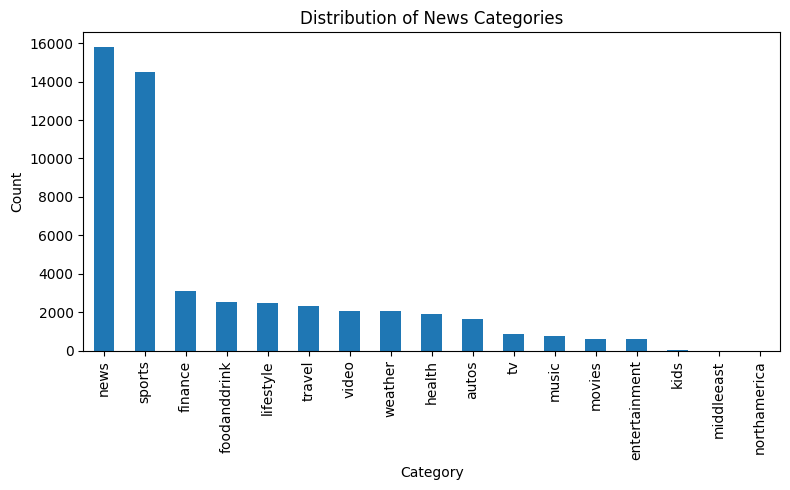

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

# Load with correct number of columns
news_df = pd.read_csv("/kaggle/input/mindataset/news.tsv", sep='\t', header=None)
news_df.columns = ['id', 'category', 'subcategory', 'title', 'abstract', 'url', 'title_entities', 'abstract_entities']

# Plot category distribution
plt.figure(figsize=(8, 5))
news_df['category'].value_counts().plot(kind='bar')
plt.title("Distribution of News Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


# Session Length Distribution
* Analyzes how many articles each user clicked in a session (from behaviors.tsv).

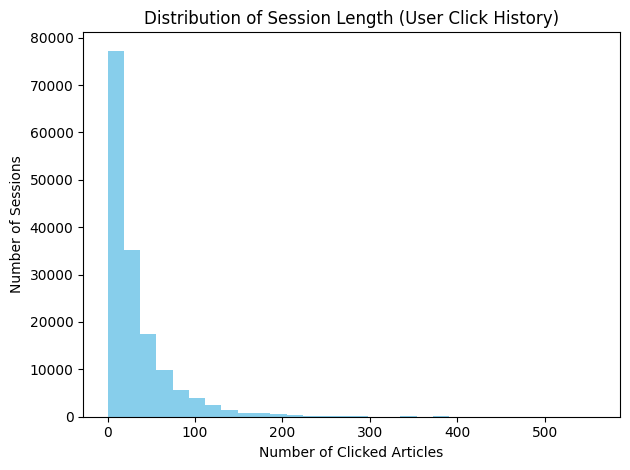

In [43]:
behaviors_df = pd.read_csv("/kaggle/input/mindataset/behaviors.tsv", sep='\t', header=None)
behaviors_df.columns = ['impression_id', 'user_id', 'time', 'history', 'impressions']

behaviors_df['click_length'] = behaviors_df['history'].fillna('').apply(lambda x: len(x.split(' ')) if x else 0)

plt.hist(behaviors_df['click_length'], bins=30, color='skyblue')
plt.title("Distribution of Session Length (User Click History)")
plt.xlabel("Number of Clicked Articles")
plt.ylabel("Number of Sessions")
plt.tight_layout()
plt.show()


In [44]:
!pip install wordcloud


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


# Word Cloud of News Titles
* Highlights frequently used words in article titles (text visualization).

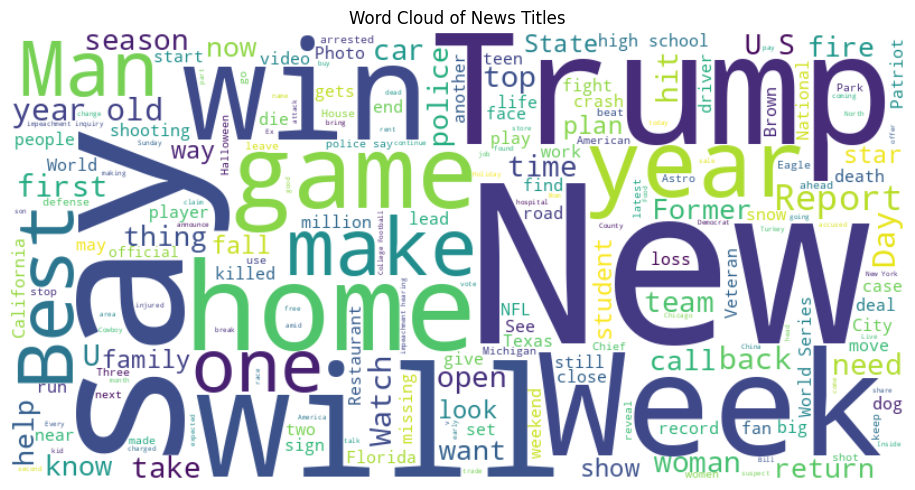

In [45]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import pandas as pd

# Load and fix the columns
news_df = pd.read_csv("/kaggle/input/mindataset/news.tsv", sep="\t", header=None)
news_df.columns = ['id', 'category', 'subcategory', 'title', 'abstract', 'url', 'title_entities', 'abstract_entities']

# Generate the Word Cloud
title_text = " ".join(news_df['title'].astype(str).values)
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(title_text)

# Plot it
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of News Titles")
plt.tight_layout()
plt.show()


# Training Loss Curve

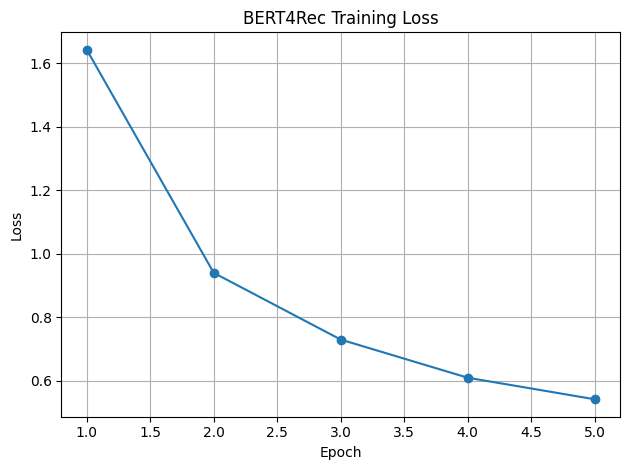

In [46]:
loss_values = [1.6419, 0.94,0.73, 0.61,0.5422]  
epochs = [1, 2, 3, 4, 5]

plt.plot(epochs, loss_values, marker='o')
plt.title("BERT4Rec Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.tight_layout()
plt.show()


# Top Clicked News Articles
* Most clicked article IDs

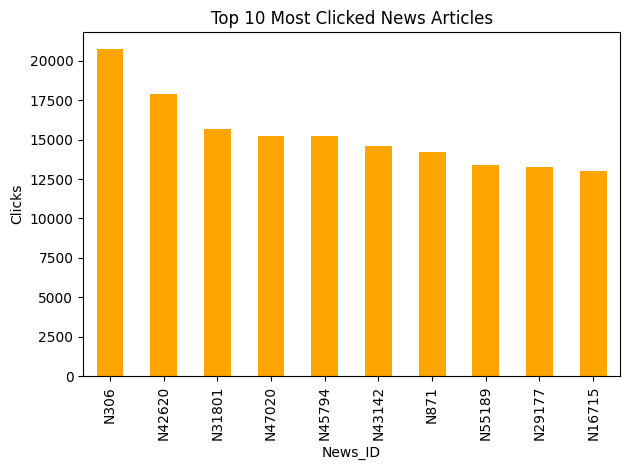

In [47]:
from collections import Counter

all_clicks = behaviors_df['history'].dropna().str.cat(sep=' ').split()
most_common = Counter(all_clicks).most_common(10)

click_df = pd.DataFrame(most_common, columns=['News_ID', 'Click_Count'])

click_df.plot(kind='bar', x='News_ID', y='Click_Count', legend=False, color='orange')
plt.title("Top 10 Most Clicked News Articles")
plt.ylabel("Clicks")
plt.tight_layout()
plt.show()
